<a href="https://colab.research.google.com/github/osoliman/HTM737/blob/main/Week12_detailed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reading the files**

In [2]:
import pandas as pd
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/X_train_clean.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/X_test_clean.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/y_test.csv')

y_train = y_train.values.ravel()

In [ ]:
X_test.head()

,WAITTIME,AGE,WINTER,NIGHT,SEX
0,0,72,0,0,2
1,-7,2,0,0,2
2,1,40,0,1,1
3,52,21,0,0,2
4,-9,54,0,0,1


# **Logistic Regression**

**Building the model**

only 3 lines needed

1- import [model]

2- define the model

3 fit the model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Evaluating the model**

Predict the probabilities in the *test* set

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 86.8%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5378
           1       0.00      0.00      0.00       817

    accuracy                           0.87      6195
   macro avg       0.43      0.50      0.46      6195
weighted avg       0.75      0.87      0.81      6195



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5375    3]
 [ 817    0]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

AUC: 0.724


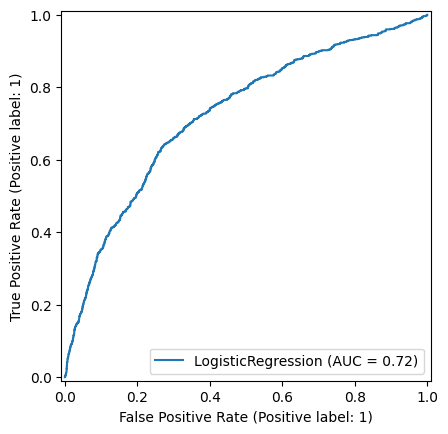

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

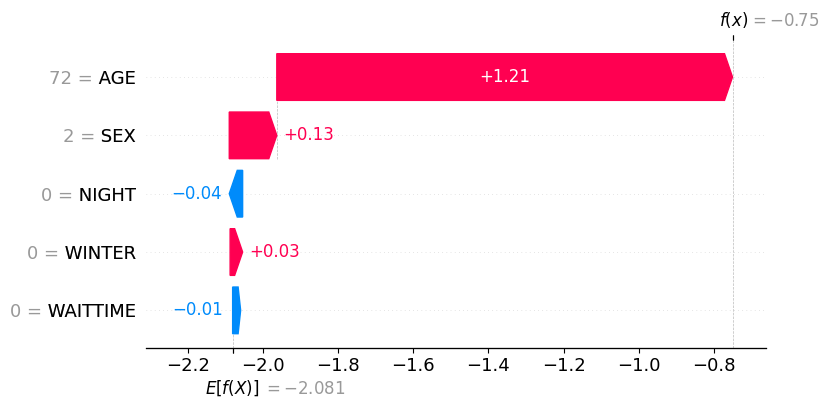

In [ ]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])  # Explain first prediction

In [ ]:
X_test.head()

,WAITTIME,AGE,WINTER,NIGHT,SEX
0,0,72,0,0,2
1,-7,2,0,0,2
2,1,40,0,1,1
3,52,21,0,0,2
4,-9,54,0,0,1


In [ ]:
first_positive_idx = (y_pred == 1).argmax()

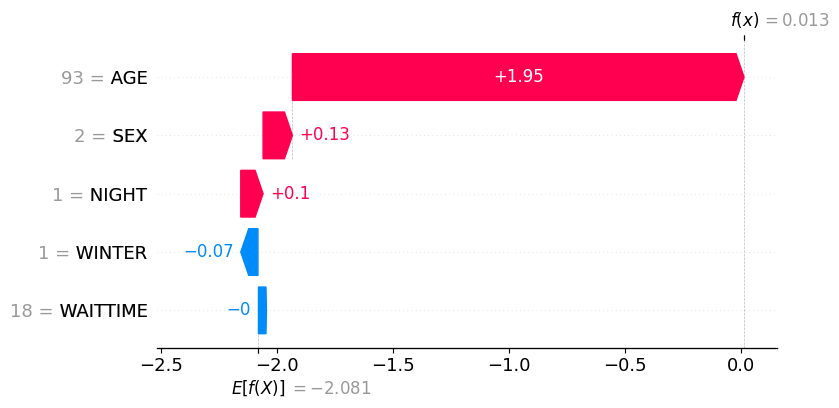

In [ ]:
shap.plots.waterfall(shap_values[first_positive_idx])

# **Random Forest**

In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 82.8%


In [ ]:
#from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      5378
           1       0.26      0.16      0.20       817

    accuracy                           0.83      6195
   macro avg       0.57      0.55      0.55      6195
weighted avg       0.80      0.83      0.81      6195



In [ ]:
#from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4999  379]
 [ 685  132]]


In [ ]:
#from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

AUC: 0.649


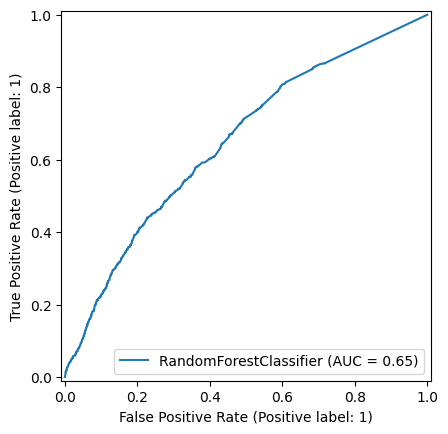

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

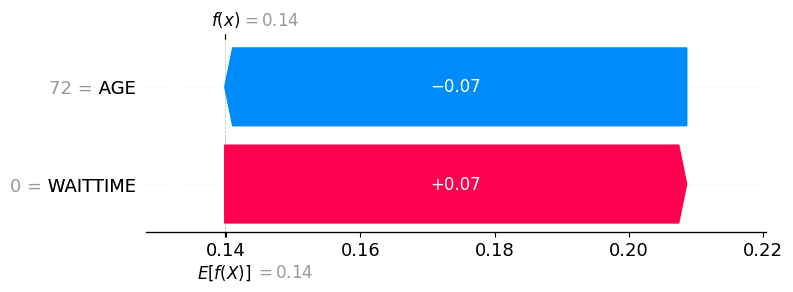

In [ ]:
i = 0  # Any row

# Compute on a small batch instead of single row
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:10])  # First 10 rows

shap.plots.waterfall(shap.Explanation(
    values=shap_values[1][i],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=X_test.columns.tolist()
))

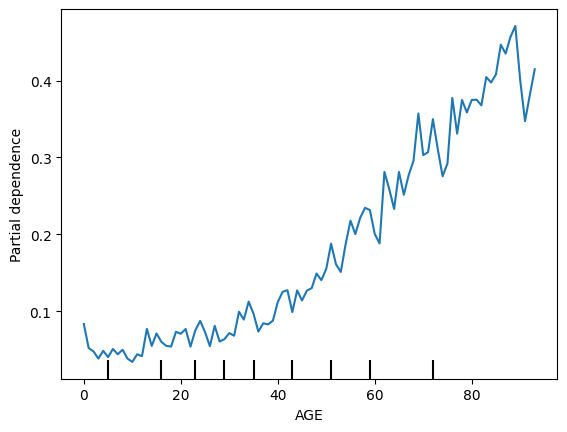

In [7]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model, X_train, ['AGE'])

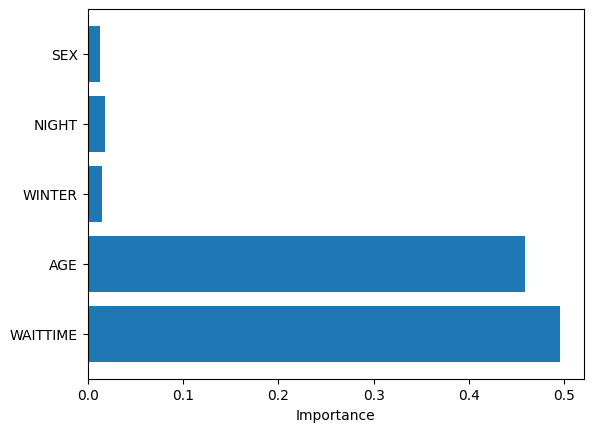

In [5]:
import matplotlib.pyplot as plt

plt.barh(X_train.columns, model.feature_importances_)
plt.xlabel('Importance')
plt.show()

# **Support Vector Machine (SVM)**

In [ ]:
from sklearn.svm import SVC

model = SVC(probability=True)  # probability=True enables predict_proba()
model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 86.8%


# **Neural Networks**

In [ ]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier()
model.fit(X_train, y_train)

MLPClassifier()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 86.5%


ExactExplainer explainer: 6196it [00:30, 173.80it/s]                          


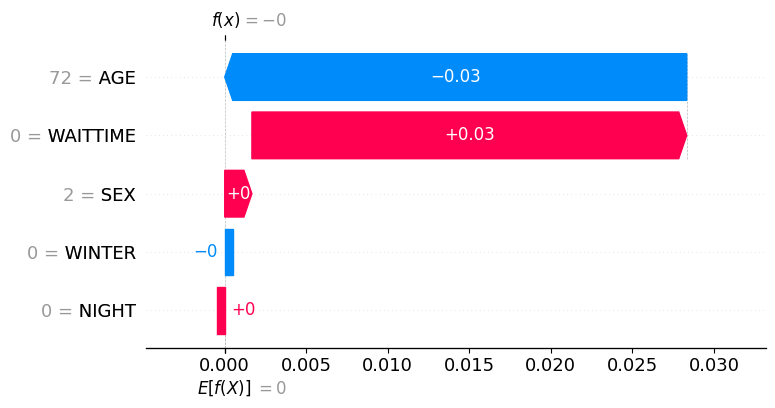

In [ ]:
import shap

explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

# **Deploying model as a sample app**

In [ ]:
#!pip install gradio -q

import gradio as gr
import pandas as pd

def predict(waittime, age, winter, night, sex):
    # Create input (adjust column order to match your X_train!)
    input_data = pd.DataFrame([[waittime, age, winter, night, sex]],
                               columns=['WAITTIME', 'AGE', 'WINTER', 'NIGHT', 'SEX'])

    # Predict
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1] * 100

    return f"Predicted Class: {int(pred)}\nProbability of Class 1: {prob:.2f}%"

# Create interface
interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="WAITTIME"),
        gr.Number(label="AGE"),
        gr.Number(label="WINTER (0 or 1)", minimum=0, maximum=1),
        gr.Number(label="NIGHT (0 or 1)", minimum=0, maximum=1),
        gr.Number(label="SEX")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Healthcare Prediction Model",
    description="Enter patient features to predict outcome"
)

# Launch with public shareable link
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8f66fd982e4c841e3b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
